# MACC Readout Modes and Detector Settings

The Lazuli detector uses a **MACC** (Multiple Accumulated Correlated Clamp) readout scheme,
common to H4RG-class infrared detectors. Understanding how MACC parameters affect noise
is key to optimising your observations.

This notebook explains:
- What the MACC parameters `(ngroups, nframes_per_group, ndrops)` mean
- How they control the exposure time
- How changing the readout mode shifts the balance between read-out noise and photon noise
- How to choose a mode for a given science case

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import slicersim

***
## 1. What is a MACC readout?

In a MACC readout each *ramp* consists of:
- **ngroups** — the number of groups per ramp
- **nframes_per_group** — frames co-added inside each group (reduces readout noise)
- **ndrops** — frames dropped between groups (usually 0)

The per-ramp integration time is set by the detector's frame time and these three numbers.
Multiple ramps (`nramps`) can be stacked to increase the total on-source time.

```
nmd = (ngroups, nframes_per_group, ndrops)
```

Let's start with a reference supernova and inspect the default configuration.

In [2]:
# Reference SN Ia at z=1.0
snia = slicersim.LazuliSupernova(redshift=1.0)

# Default readout config
cfg = snia.get_readout_config()
print("Default readout config:")
print(cfg)

Default readout config:
{'nmd': [16, 8, 0], 'nramps': 1}


In [3]:
print(f"Default exposure time: {snia.get_exposure_time():.1f} s")

Default exposure time: 362.2 s


***
## 2. Changing the readout mode

`change_detector(nmd, nramps)` lets you set any MACC configuration.
The exposure time is determined by the detector frame time and `nmd`.

In [4]:
# Short ramp: few groups, few frames
snia.change_detector(nmd=(10, 4, 0), nramps=1)
print(f"Short ramp  (10, 4, 0) x1 ramp:  {snia.get_exposure_time():.1f} s")

# Medium ramp
snia.change_detector(nmd=(40, 8, 0), nramps=1)
print(f"Medium ramp (40, 8, 0) x1 ramp:  {snia.get_exposure_time():.1f} s")

# Long ramp
snia.change_detector(nmd=(64, 8, 0), nramps=1)
print(f"Long ramp   (64, 8, 0) x1 ramp:  {snia.get_exposure_time():.1f} s")

# Long ramp x2
snia.change_detector(nmd=(64, 8, 0), nramps=2)
print(f"Long ramp   (64, 8, 0) x2 ramps: {snia.get_exposure_time():.1f} s")

Short ramp  (10, 4, 0) x1 ramp:  113.2 s
Medium ramp (40, 8, 0) x1 ramp:  905.6 s
Long ramp   (64, 8, 0) x1 ramp:  1449.0 s
Long ramp   (64, 8, 0) x2 ramps: 2897.9 s


***
## 3. Effect on read-out noise vs. photon noise

The MACC slope fitting reduces the *effective* read-out noise (RON) compared to a single read.
Longer ramps → lower effective RON → photon noise becomes the dominant term.

Let's compare three readout modes and look at the variance budget.

/Users/rigault/miniforge3/envs/lazuli/lib/python3.13/site-packages/slicersim/simulation.py:768: UserWarning: failed to parse which='optics__emissivity'
  warnings.warn(f"failed to parse {which=}")


/Users/rigault/miniforge3/envs/lazuli/lib/python3.13/site-packages/slicersim/simulation.py:768: UserWarning: failed to parse which='optics__emissivity'
  warnings.warn(f"failed to parse {which=}")


/Users/rigault/miniforge3/envs/lazuli/lib/python3.13/site-packages/slicersim/simulation.py:768: UserWarning: failed to parse which='optics__emissivity'
  warnings.warn(f"failed to parse {which=}")


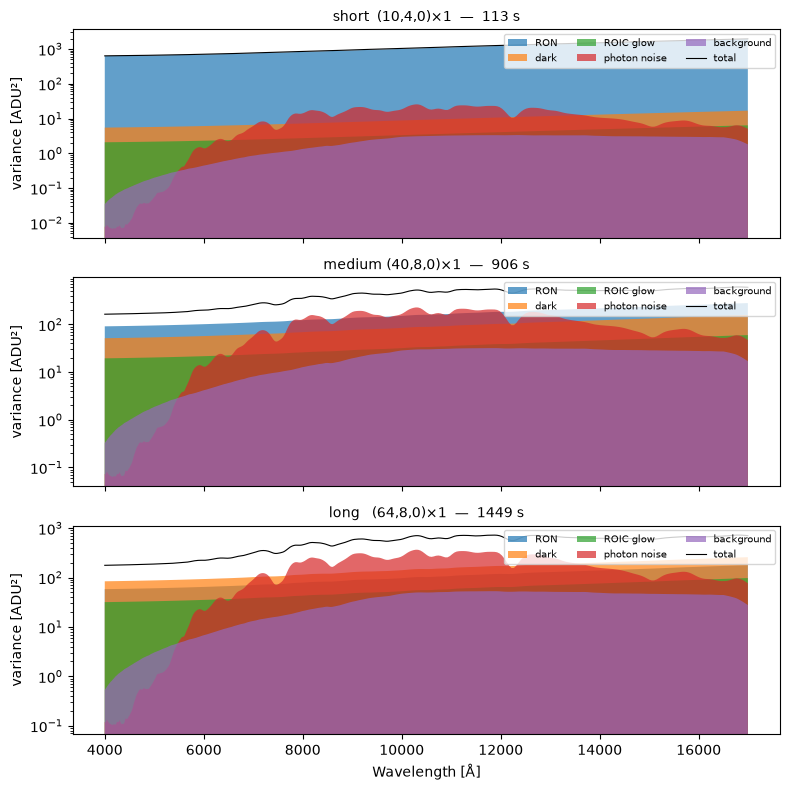

In [5]:
modes = {
    "short  (10,4,0)×1": (10, 4, 0, 1),
    "medium (40,8,0)×1": (40, 8, 0, 1),
    "long   (64,8,0)×1": (64, 8, 0, 1),
}

fig, axes = plt.subplots(len(modes), 1, figsize=(8, 8), sharex=True)

for ax, (label, (ng, nf, nd, nr)) in zip(axes, modes.items()):
    snia.change_detector(nmd=(ng, nf, nd), nramps=nr)
    vc = snia.get_variance_contribution()
    lbda = vc["lbda"].values
    total = vc["variance"].values

    ax.fill_between(lbda, vc["ron"],        label="RON",         alpha=0.7)
    ax.fill_between(lbda, vc["dark"],       label="dark",        alpha=0.7)
    ax.fill_between(lbda, vc["roic_glow"],  label="ROIC glow",   alpha=0.7)
    ax.fill_between(lbda, vc["pointsource"],label="photon noise",alpha=0.7)
    ax.fill_between(lbda, vc["background"], label="background",  alpha=0.7)
    ax.plot(lbda, total, "k-", lw=0.8, label="total")

    exptime = snia.get_exposure_time()
    ax.set_title(f"{label}  —  {exptime:.0f} s", fontsize=10)
    ax.set_ylabel("variance [ADU²]")
    ax.set_yscale("log")
    ax.legend(fontsize=7, loc="upper right", ncol=3)

axes[-1].set_xlabel("Wavelength [Å]")
plt.tight_layout()

With longer ramps the RON contribution falls relative to the source photon noise,
but the total exposure time increases.

***
## 4. SNR as a function of exposure time for different modes

How quickly does the SNR build up with exposure time for different readout strategies?

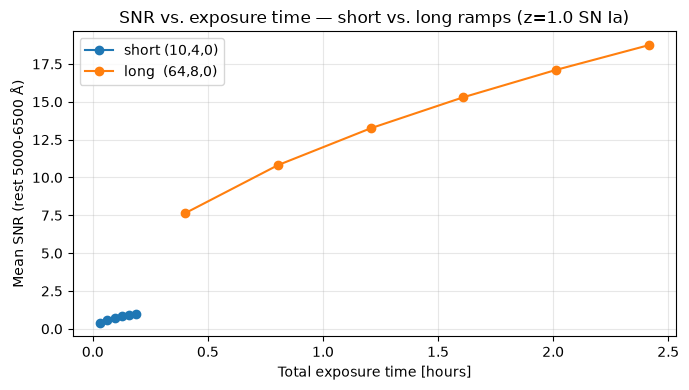

In [6]:
# Fix the target to its default and sweep over number of ramps
snia = slicersim.LazuliSupernova(redshift=1.0)

nmd_options = {
    "short (10,4,0)": (10, 4, 0),
    "long  (64,8,0)": (64, 8, 0),
}

fig, ax = plt.subplots(figsize=(7, 4))

for label, nmd in nmd_options.items():
    exptimes, snrs = [], []
    for nr in range(1, 7):
        snia.change_detector(nmd=nmd, nramps=nr)
        lbda, flux, var = snia.get_spectrum(incl_error=False)
        # mean SNR over rest-frame 5000-6500 A
        z = snia.get_properties("redshift")
        mask = (lbda > 5000 * (1 + z)) & (lbda < 6500 * (1 + z))
        snr_mean = np.mean(flux[mask] / np.sqrt(var[mask]))
        exptimes.append(snia.get_exposure_time() / 3600)
        snrs.append(snr_mean)
    ax.plot(exptimes, snrs, "o-", label=label)

ax.set_xlabel("Total exposure time [hours]")
ax.set_ylabel("Mean SNR (rest 5000-6500 Å)")
ax.set_title("SNR vs. exposure time — short vs. long ramps (z=1.0 SN Ia)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

Long ramps are more efficient per unit time because read-out noise is amortised over more photons.

***
## 5. Using `setup_to_snr` to let slicersim choose the mode

Rather than hand-tuning the MACC parameters, `setup_to_snr()` searches the space of allowed
readout modes and selects the one that reaches your SNR target with the minimum exposure time.

In [7]:
snia = slicersim.LazuliSupernova(redshift=1.0)
_ = snia.setup_to_snr(15, per_resolution=True, lbda_range=[5000, 7000], frame="rest")

cfg = snia.get_readout_config()
print(f"Chosen readout: nmd={cfg['nmd']},  nramps={cfg['nramps']}")
print(f"Total exposure: {snia.get_exposure_time()/3600:.2f} hours")

Chosen readout: nmd=(64, 8, 0),  nramps=2
Total exposure: 0.80 hours


***
## Summary

| Parameter | Effect |
|-----------|--------|
| More `ngroups` | Longer ramp → lower effective RON, more photons per ramp |
| More `nframes_per_group` | Co-adds reduce RON within each group |
| More `nramps` | Extends total exposure time (adds ramp-reset overhead) |
| `setup_to_snr()` | Automatically picks the optimal MACC mode for a given SNR target |